In [1]:
import pandas as pd

from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [2]:
from helper import compute_scalar_ability, process_reference_composite

# med_qa & mmlu

In [3]:
results_medqa = process_reference_composite(resmat, theta_df, a_df, b_series, ['med_qa'])

Mean unit vector:  [-0.2479383  -0.17674813  0.33735496  0.10071559  0.2589872  -0.21787395
 -0.19583313  0.21365169 -0.30194694  0.06498487  0.00390616  0.2815828
 -0.03198322  0.34514776  0.04327939  0.3220051   0.01406873 -0.29379958
  0.3128388 ]
Mean unit vector:  [-0.20584089  0.11468188  0.3278384  -0.03749165 -0.2088111   0.1870712
 -0.06810404  0.28732058 -0.34543604 -0.04102236 -0.22682638  0.04800078
 -0.25028682  0.0902601   0.00736952  0.31629273  0.33538204  0.41548142
  0.19761086]
Used pre-computed direction vector. [ 1.4050616e-01 -1.8426207e-01 -2.3093991e-01  7.3155940e-02
  3.0302235e-01 -2.6494783e-01  5.1216255e-03 -2.2601403e-01
  2.6425907e-01  6.5744445e-02  2.3019677e-01  4.0488858e-02
  2.5857022e-01  1.9503498e-02 -5.3533708e-04 -2.1913882e-01
 -3.5438102e-01 -5.4196936e-01 -1.0549491e-01]
Used pre-computed direction vector. [-0.13404885  0.18012838  0.23276205 -0.07326433 -0.30693433  0.27024037
 -0.00624283  0.23145708 -0.2631772  -0.06502266 -0.24051437 -

In [4]:
results_mmlu = process_reference_composite(resmat, theta_df, a_df, b_series, ['mmlu'])

Mean unit vector:  [-2.1874996e-01 -1.3086928e-01  3.6171278e-01  9.0095147e-02
  3.5656613e-01 -3.3572370e-01 -2.0591977e-01  8.9912012e-02
 -2.1754168e-01  1.4253540e-01 -8.0801882e-02  2.7349001e-01
 -4.4526353e-02  2.9584989e-01  6.2102485e-02  1.8939689e-01
  3.8638034e-05 -3.7063602e-01  3.0026037e-01]
Mean unit vector:  [-0.14544667 -0.16055015  0.00561517  0.04613464 -0.27172148  0.33878922
 -0.00640052  0.4350865  -0.33368748 -0.22956795  0.24246246  0.07451088
  0.01416348  0.21410826 -0.04990262  0.48214725  0.07059041  0.21824293
  0.10467207]
Used pre-computed direction vector. [-1.4106373e-01 -1.5243277e-01 -6.1693289e-03  4.6319682e-02
 -2.8316689e-01  3.4743315e-01 -1.1150494e-04  4.3280888e-01
 -3.2940045e-01 -2.3314898e-01  2.4925926e-01  6.7076653e-02
  9.0846289e-03  2.0494470e-01 -5.3160239e-02  4.7313625e-01
  7.4257463e-02  2.3157617e-01  9.5194183e-02]
Used pre-computed direction vector. [-1.3874140e-01 -1.5657391e-01 -5.5848965e-03  4.3366384e-02
 -2.8289512e-0

In [5]:
# results_check = process_reference_composite(resmat, theta_df, a_df, b_series, ['civil_comments'])

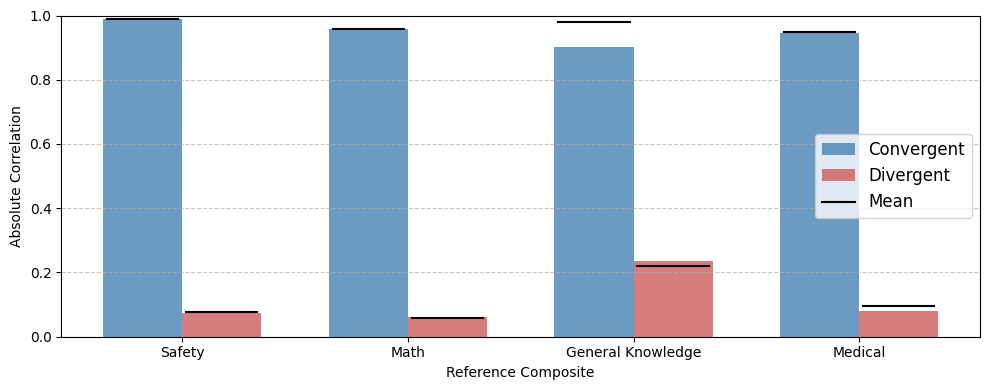

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Sample data
categories = ['Safety', 'Math', 'General Knowledge', 'Medical']

# --- Data ---
# Bar heights are the 'eigen' values
bar_heights_convergent = np.absolute([
    0.9885017421602788,  # Safety
    0.9577276365666086,  # Math
    0.9020015944762607,  # General Knowledge (MMLU)
    0.9451768447607716   # Medical (MedQA)
])

bar_heights_divergent = np.absolute([
    -0.07372937112780306, # Safety
    0.06141862414136114,  # Math
    -0.23693341583576796, # General Knowledge (MMLU)
    0.08087653615094814   # Medical (MedQA)
])

# Line markers are the 'mean' values
line_values_convergent = np.absolute([
    0.9885017421602788,  # Safety
    0.9578550469115413,  # Math
    0.9786817105932852,  # General Knowledge (MMLU)
    0.9491664447272828   # Medical (MedQA)
])

line_values_divergent = np.absolute([
    -0.0762964761539245,  # Safety
    0.05946441299256695, # Math
    -0.2187698260399615,  # General Knowledge (MMLU)
    0.0958934152091672   # Medical (MedQA)
])


x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
rects1 = ax.bar(x - width/2, bar_heights_convergent, width, label='Convergent', color='steelblue', alpha=0.8)
rects2 = ax.bar(x + width/2, bar_heights_divergent, width, label='Divergent', color='indianred', alpha=0.8)

# --- Function to add horizontal line markers ---
def add_line_markers(rects, second_values, protrusion_amount=-0.05):
    
    for i, rect in enumerate(rects):
        y_value = second_values[i]
        
        # --- MODIFICATION ---
        # To protrude left, subtract from the bar's starting x-position.
        x_start = rect.get_x() - rect.get_width() * protrusion_amount
        
        # To protrude right, add the bar's width PLUS the protrusion amount.
        x_end = rect.get_x() + rect.get_width() * (1 + protrusion_amount)
        
        # Plot the horizontal line
        ax.plot([x_start, x_end], [y_value, y_value], color='black', linewidth=1.5)

add_line_markers(rects1, line_values_convergent)
add_line_markers(rects2, line_values_divergent)
# --- MODIFICATION: Create and place the legend at the top ---
handles, labels = ax.get_legend_handles_labels()
mean_line_handle = Line2D([0], [0], color='black', linewidth=1.5, label='Mean')
handles.append(mean_line_handle)
# Add some text for labels, title and axes ticks
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('Reference Composite')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(handles=handles, frameon=True, loc='center right',  fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig('../result/selective_scale_correlations.pdf', bbox_inches='tight')
fig.tight_layout()
plt.show()

In [7]:
scores_mmlu_pure = results_mmlu['scores']
scores_medqa_pure = results_medqa['scores']

print('scores correlation', scores_mmlu_pure.corr(scores_medqa_pure))

mean_mmlu_pure = scores_mmlu_pure.mean()
mean_medqa_pure = scores_medqa_pure.mean()

v1 = results_mmlu['v']
v2 = results_medqa['v']

scores correlation 0.8652654495699577


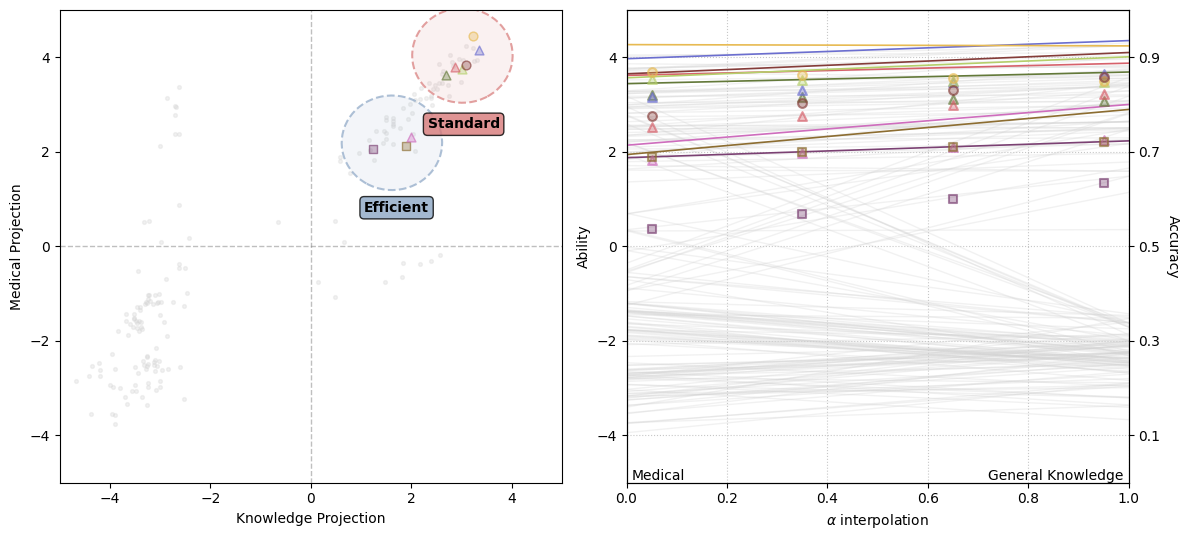

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D

# Create combined figure with two subplots
# ax1 will now be the LEFT plot, ax2 will be the RIGHT plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Model classification and colors (shared between both plots)
model_classification = {
    'deepseek-ai/deepseek-v3': 'math',
    'meta/llama-3.1-70b-instruct-turbo': 'math',
    'meta/llama-3.1-405b-instruct-turbo': 'math',
    'anthropic/claude-3-haiku-20240307': 'safety',
    'openai/gpt-4o-2024-08-06': 'general',
    'google/gemini-1.5-pro-002': 'general',
    'qwen/qwen2-72b-instruct': 'math',
    'cohere/command-r': 'safety',
    'databricks/dbrx-instruct': 'math'
}

models_to_name = {
    'deepseek-ai/deepseek-v3': 'DeepSeek v3',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70b Instruct',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405b Instruct',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku (July 24)',
    'openai/gpt-4o-2024-08-06': 'GPT 4o (June 24)',
    'google/gemini-1.5-pro-002': 'Gemini 1.5 Pro',
    'qwen/qwen2-72b-instruct': 'Qwen 2 72b Instruct',
    'cohere/command-r': 'Command R',
    'databricks/dbrx-instruct': 'DBRX Instruct'
}

models_to_highlight = model_classification.keys()

# Define colors and markers for highlighted models (shared)
highlight_cmap = plt.get_cmap('tab20b')
# Clip the colormap to avoid overly bright/dark colors at the ends
from matplotlib.colors import LinearSegmentedColormap
def clipped_cmap(cmap, minval=0.08, maxval=0.92, n=256):
    return LinearSegmentedColormap.from_list(
        f'clipped({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )
highlight_cmap = clipped_cmap(highlight_cmap, minval=0.1)
num_highlight = len(models_to_highlight)
highlight_colors = [highlight_cmap(i / max(num_highlight - 1, 1)) for i in range(num_highlight)]
highlight_color_map = dict(zip(models_to_highlight, highlight_colors))


# ===== LEFT SUBPLOT: SCATTER PLOT (Formerly RIGHT) =====
# Get all models
mmlu_mean_full = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm', 'med_qa'])]].mean(axis=1)
all_indices = mmlu_mean_full.index

# Get PC1 and PC2 scores for all models
all_pc1 = scores_mmlu_pure.loc[all_indices]
all_pc2 = scores_medqa_pure.loc[all_indices]

# First, plot all models as grey dots (Others)
other_indices = [idx for idx in all_indices if idx not in models_to_highlight]
other_pc1 = scores_mmlu_pure.loc[other_indices]
other_pc2 = scores_medqa_pure.loc[other_indices]

ax1.scatter(other_pc1, other_pc2,
           color='lightgray',
           marker='.',
           s=30,
           alpha=0.3,
           label='Other Models')

# Plot highlighted models with unique colors and shapes
highlighted_pc1 = scores_mmlu_pure.loc[models_to_highlight]
highlighted_pc2 = scores_medqa_pure.loc[models_to_highlight]

for model_name, pc1_score, pc2_score in zip(models_to_highlight, highlighted_pc1, highlighted_pc2):
    model_type = model_classification[model_name]

    if model_type == 'math':
        marker_shape = '^'
    elif model_type == 'safety':
        marker_shape = 's'
    elif model_type == 'general':
        marker_shape = 'o'

    color = highlight_color_map[model_name]
    face_color = (*color[:3], 0.35)
    edge_color = (*color[:3], 0.65)

    ax1.scatter(pc1_score, pc2_score,
               color=face_color,
               marker=marker_shape,
               s=40,
               edgecolors=edge_color,
               linewidth=1,
               label=model_name,
               zorder=3)

# Add cluster shading regions
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as mcolors

# Define cluster groups based on model positions
cluster_A_models = ['deepseek-ai/deepseek-v3', 'meta/llama-3.1-70b-instruct-turbo', 'openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002',
                    'meta/llama-3.1-405b-instruct-turbo', 'qwen/qwen2-72b-instruct']
cluster_B_models = ['cohere/command-r', 'databricks/dbrx-instruct', 'anthropic/claude-3-haiku-20240307']

# Get positions for each cluster
cluster_A_pos = [(scores_mmlu_pure.loc[model], scores_medqa_pure.loc[model]) for model in cluster_A_models if model in models_to_highlight]
cluster_B_pos = [(scores_mmlu_pure.loc[model], scores_medqa_pure.loc[model]) for model in cluster_B_models if model in models_to_highlight]

# Define cluster colors (soft pastels)
cluster_colors = {
    'A': '#D77A79',
    'B': '#8CA6C5'
}

# Function to create rotated ellipse around cluster points
def create_cluster_ellipse(positions, ax, color, alpha=0.2, padding=1, rotation=-30, ratio=1):
    if len(positions) < 2:
        # For single points, create a small circle
        if len(positions) == 1:
            x, y = positions[0]
            circle = Circle((x, y), padding*1.2, color=color, alpha=alpha)
            ax.add_patch(circle)
        return

    # Calculate center and span
    positions = np.array(positions)
    # Center is midpoint between most distant x and y coordinates
    center_x = (np.max(positions[:, 0]) + np.min(positions[:, 0])) / 2
    center_y = (np.max(positions[:, 1]) + np.min(positions[:, 1])) / 2

    # Calculate width and height with moderate padding
    width = (np.max(positions[:, 0]) - np.min(positions[:, 0]))*ratio + 2*padding
    height = (np.max(positions[:, 1]) - np.min(positions[:, 1])) + 2*padding

    # Ensure minimum size but not too large
    width = max(width, 2.0)
    height = max(height, 2.0)
    color = mcolors.to_rgba(color)

    face_color = (*color[:3], 0.1)
    edge_color = (*color[:3], 0.7)

    # Create rotated ellipse
    ellipse = Ellipse(
        (center_x, center_y), width, height,
        angle=rotation,
        facecolor=face_color,
        edgecolor=edge_color,
        zorder=1,
        linewidth=1.5,
        linestyle='--'
    )
    ax.add_patch(ellipse)

# Add cluster ellipses and labels
if cluster_A_pos:
    create_cluster_ellipse(cluster_A_pos, ax1, cluster_colors['A'], padding=0.5, rotation=30, ratio=1.25)
    # Add label for cluster A
    center_x = np.mean([pos[0] for pos in cluster_A_pos])
    center_y = np.mean([pos[1] for pos in cluster_A_pos])
    ax1.text(center_x, center_y - 1.5, 'Standard', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['A'], alpha=0.8))

if cluster_B_pos:
    create_cluster_ellipse(cluster_B_pos, ax1, cluster_colors['B'], padding=0)
    # Add label for cluster B
    center_x = np.mean([pos[0] for pos in cluster_B_pos])
    center_y = np.mean([pos[1] for pos in cluster_B_pos])
    ax1.text(center_x, center_y - 1.5, 'Efficient', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['B'], alpha=0.8))

# Add quadrant lines
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Customize the left plot
ax1.set_xlabel('Knowledge Projection')
ax1.set_ylabel('Medical Projection')
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)


# ===== RIGHT SUBPLOT: SELECTIVE SCALE ACCURACY =====
p_dim = len(theta)

# In your text labels, "Medical" corresponds to the airbench vector
avg_mmlu_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['mmlu'])]].mean(axis=1)
avg_medical_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['med_qa'])]].mean(axis=1)

# Calculate and Scale Data
a_values = np.linspace(0, 1, 50)
p_matrix = np.zeros((p_dim, len(a_values)))
for i, model_theta in enumerate(theta):
    for j, a in enumerate(a_values):
        p = model_theta @ (a * results_mmlu['v'] + (1 - a) * results_medqa['v']) - (a * mean_mmlu_pure + (1 - a) * mean_medqa_pure)
        p_matrix[i, j] = p

scaler = MinMaxScaler(feature_range=(-5, 5))
scaler.fit([[0], [1]])
def scale_accuracy(accuracy):
    return scaler.transform(np.array(accuracy).reshape(-1, 1)).flatten() if np.ndim(accuracy) else scaler.transform([[accuracy]])[0, 0]

# Plot the lines
for i in range(p_matrix.shape[0]):
    model_name = theta_df.index[i]
    if model_name in models_to_highlight:
        color = highlight_color_map[model_name]
        ax2.plot(a_values, p_matrix[i, :], linewidth=1.2, label=models_to_name.get(model_name, model_name), alpha=1.0, color=color, zorder=10)

        mmlu_acc = avg_mmlu_acc.get(model_name, 0)
        medical_acc = avg_medical_acc.get(model_name, 0)

        scaled_mmlu = scale_accuracy(mmlu_acc)
        scaled_medical = scale_accuracy(medical_acc)

        x_dots = np.linspace(0.05, 0.95, 4)
        y_dots = x_dots * scaled_mmlu + (1 - x_dots) * scaled_medical

        # Determine marker shape based on classification
        model_type = model_classification.get(model_name)
        if model_type == 'math':
            marker_shape = '^'
        elif model_type == 'safety':
            marker_shape = 's'
        elif model_type == 'general':
            marker_shape = 'o'

        face_color = (*color[:3], 0.35)
        edge_color = (*color[:3], 0.65)

        ax2.scatter(x_dots, y_dots,
                   facecolor=face_color,
                   edgecolor=edge_color,
                   s=40,
                   linewidths=1.5,
                   marker=marker_shape,
                   zorder=11)
    else:
        ax2.plot(a_values, p_matrix[i, :], color='lightgray', alpha=0.3, lw=1)

# Add right y-axis for scaled average accuracy score
ax2_right = ax2.twinx()
ax2_right.set_ylim(-5, 5)
ax2_right.set_ylabel('Accuracy', rotation=270, va='bottom')
ax2_right.tick_params(axis='y')

# Set right y-axis to have the same ticks as the left: -4, -2, 0, 2, 4
left_ticks = np.array([-4, -2, 0, 2, 4])
# Inverse transform to get the corresponding accuracy values for these ticks
acc_ticks = scaler.inverse_transform(left_ticks.reshape(-1, 1)).flatten()
ax2_right.set_yticks(left_ticks)
ax2_right.set_yticklabels([f"{x:.1f}" for x in acc_ticks])

# Format the right plot
ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 5)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.text(0.01, ax2.get_ylim()[0], 'Medical', va='bottom')
ax2.text(0.99, ax2.get_ylim()[0], 'General Knowledge', ha='right', va='bottom')
ax2.set_xlabel(r'$\alpha$ interpolation')
ax2.set_ylabel('Ability')



plt.tight_layout()
plt.savefig('../result/combined_mmlu_medical_analysis.pdf', bbox_inches='tight')
plt.show()

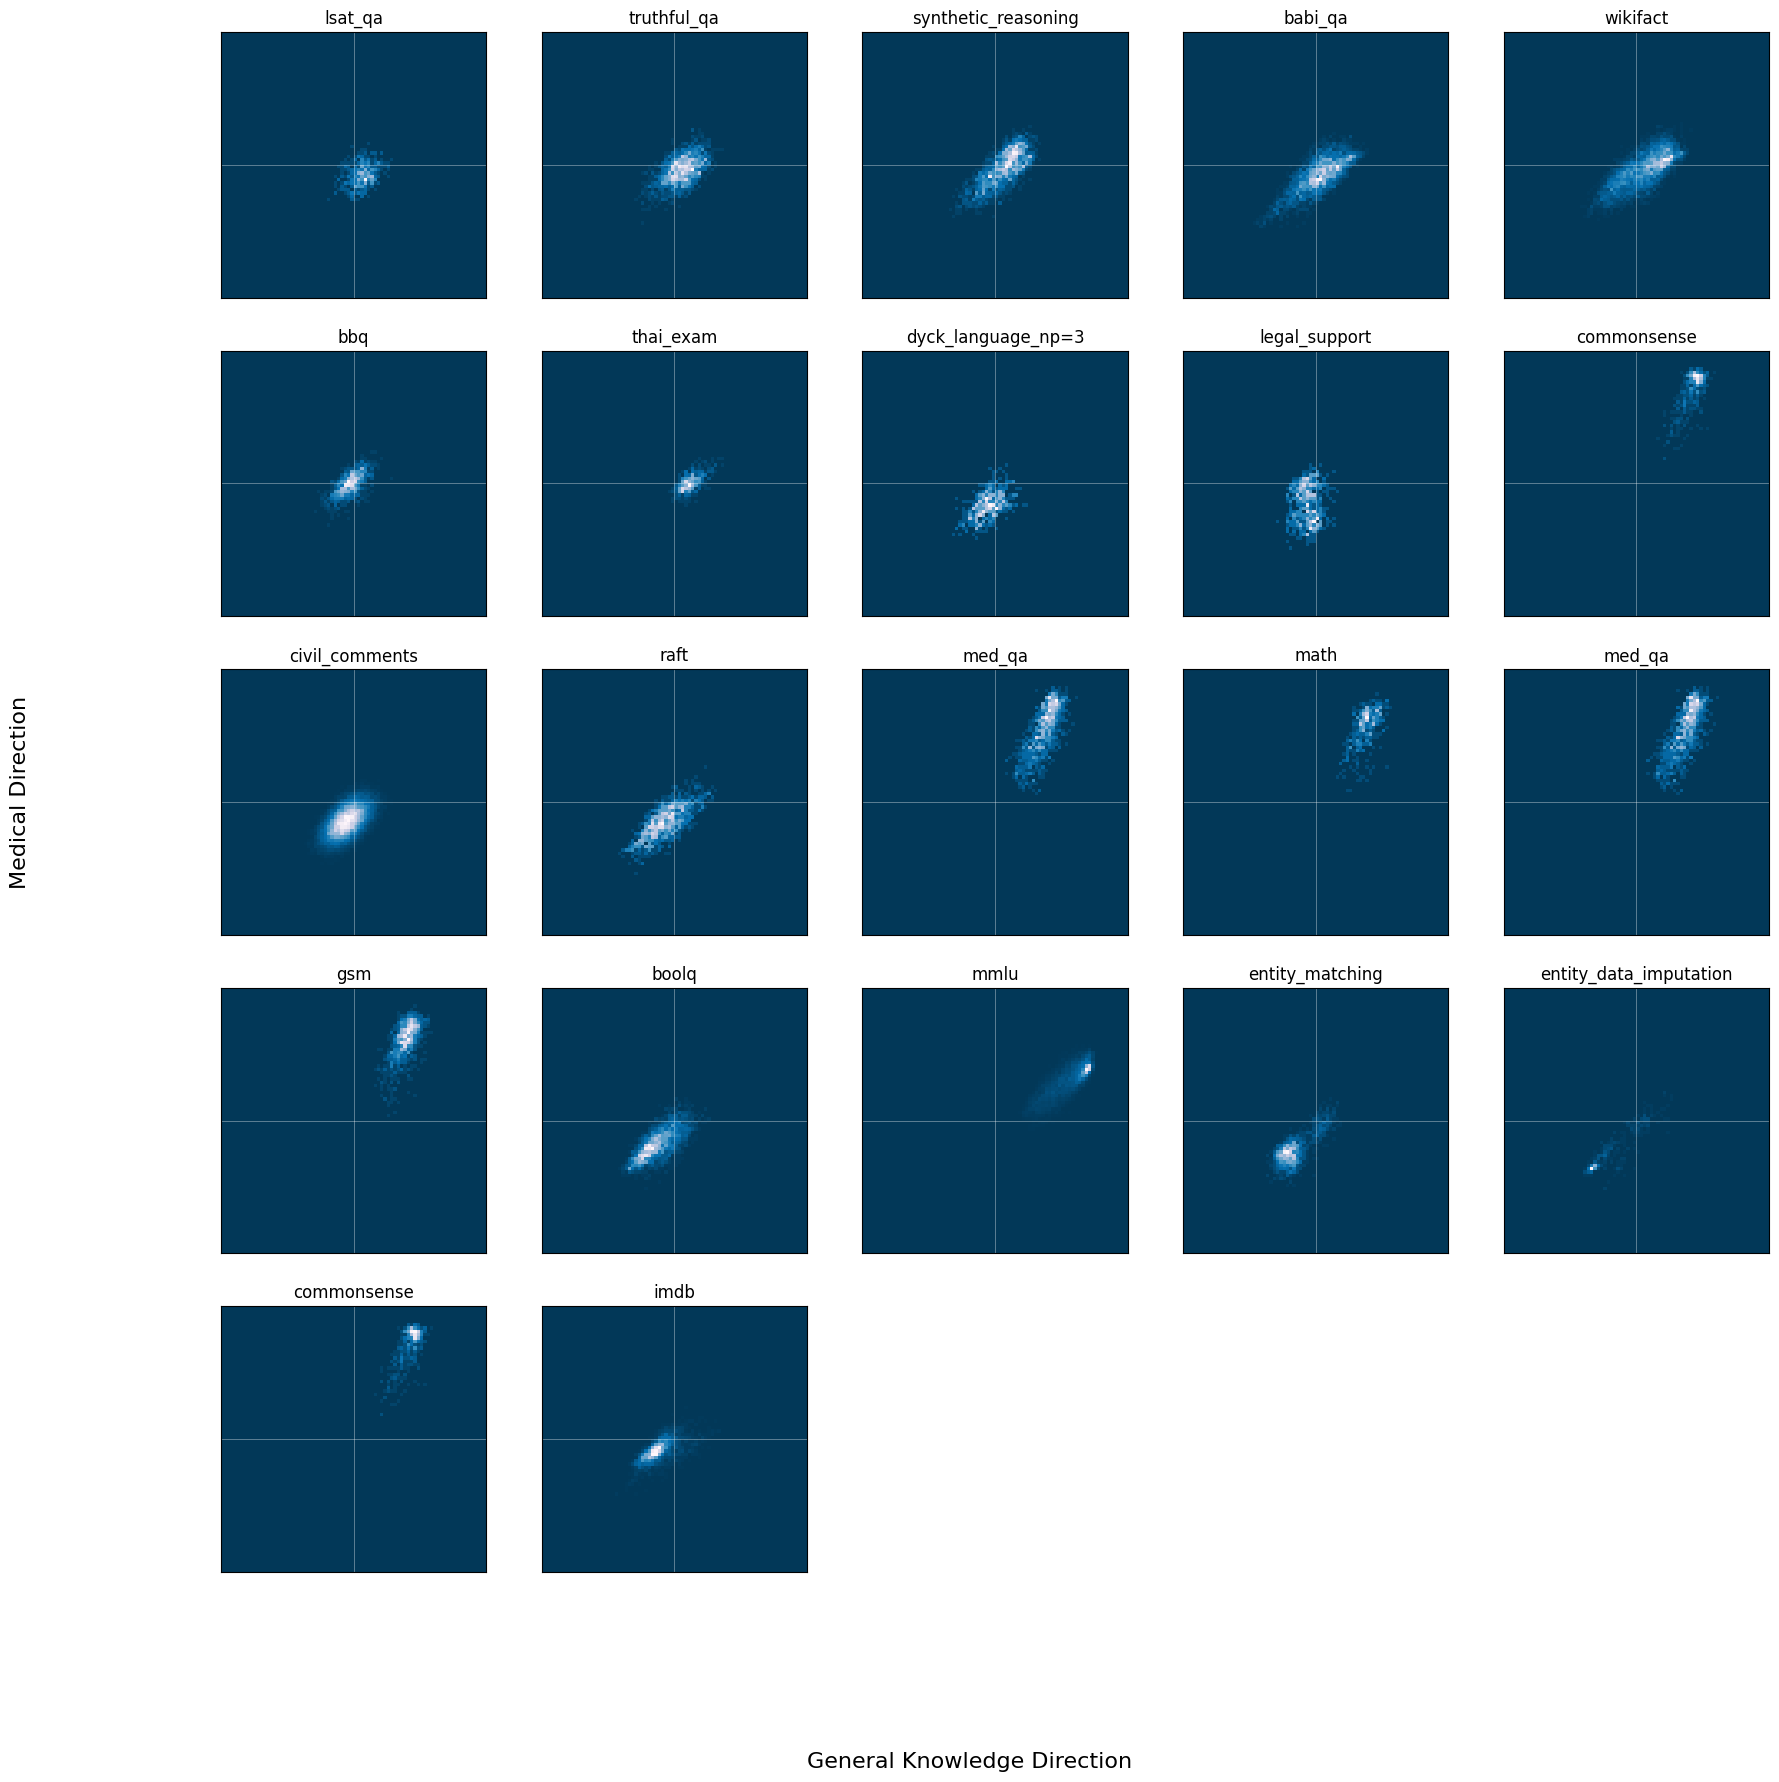

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
    'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support',
    'commonsense', 'civil_comments', 'raft', 'med_qa', 'math',
    'med_qa', 'gsm', 'boolq', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'commonsense', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = results_mmlu['v']
v2 = results_medqa['v']
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("General Knowledge Direction", fontsize=16)
fig.supylabel("Medical Direction", fontsize=16)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings_full.pdf')
plt.show()

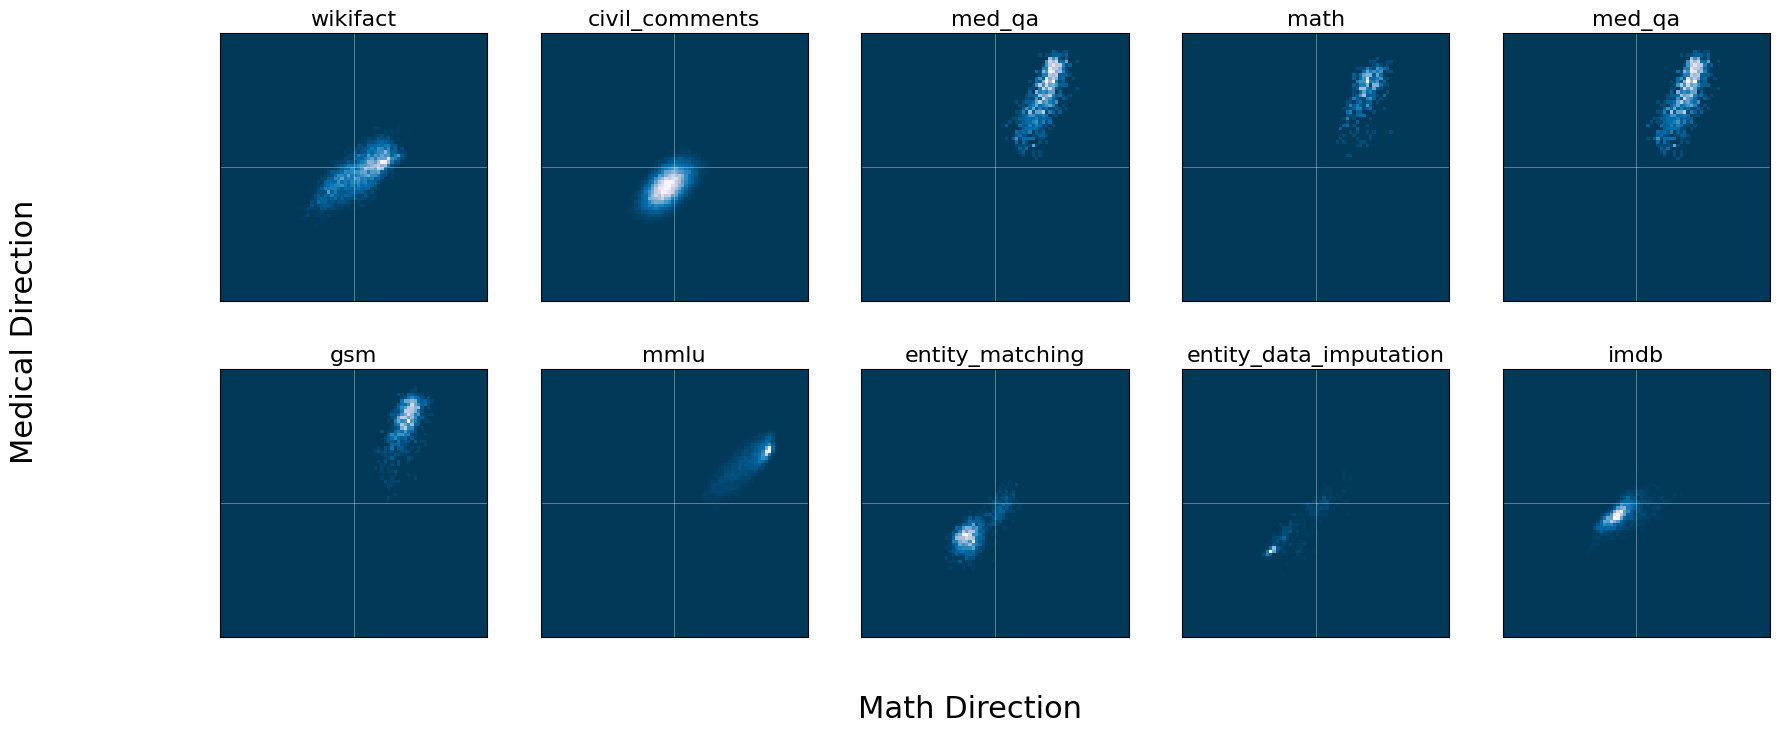

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'wikifact',
    'civil_comments', 'med_qa', 'math',
    'med_qa', 'gsm', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = results_mmlu['v']
v2 = results_medqa['v']
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=16)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("Math Direction", fontsize=22)
fig.supylabel("Medical Direction", fontsize=22)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings.pdf')
plt.show()

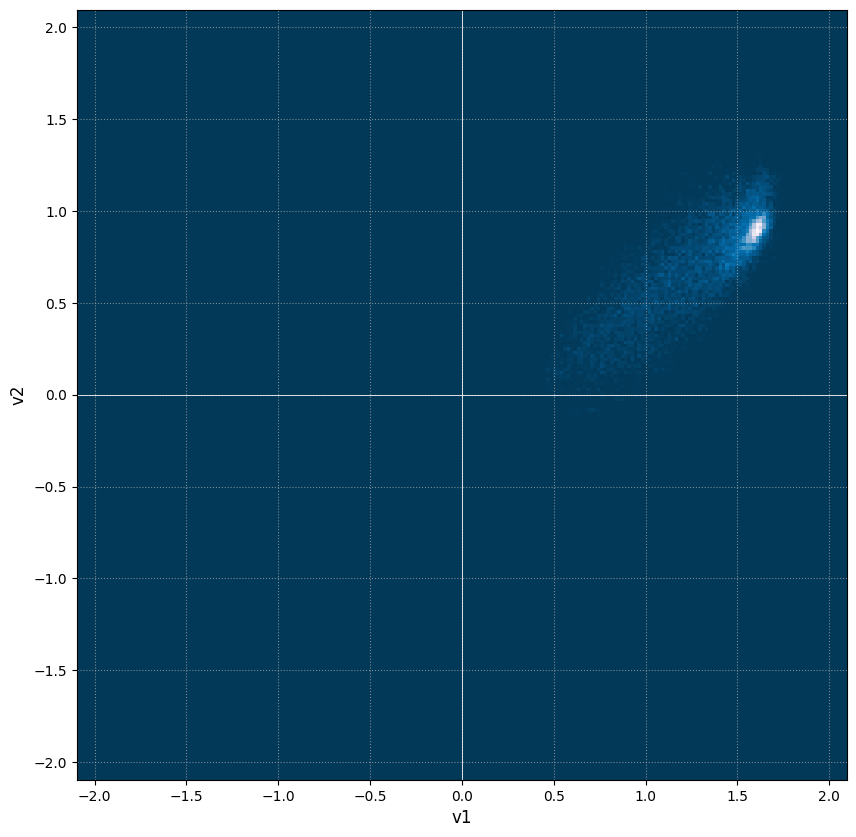

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

examine_dataset = ['mmlu']

models = resmat.index.to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(examine_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

med_qa_vectors = a_df.loc[scenario_questions].to_numpy()
v1 = results_mmlu['v']
v2 = results_medqa['v']


# --- 3. Project the MedQA vectors onto the new basis ---
# The new coordinates are simply the dot products with the normalized basis vectors.
# This section remains the same.

# coords_x will be the projection onto the v1 direction
coords_x = med_qa_vectors @ v1
# coords_y will be the projection onto the v2 direction
coords_y = med_qa_vectors @ v2


# --- 4. Create the Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.hist2d(coords_x, coords_y, bins=250, range=hist_range, cmap='PuBu_r')

ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='white', lw=0.5, alpha=0.5)
ax.axvline(0, color='white', lw=0.5, alpha=0.5)
ax.set_facecolor('black')

ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)

# --- 5. Format the Plot ---
# This section is mostly the same, with an updated title.
# Set axis limits to be symmetrical and slightly larger than the data
max_lim = max(np.abs(coords_x).max(), np.abs(coords_y).max()) * 1.15
ax.set_xlim([-max_lim, max_lim])
ax.set_ylim([-max_lim, max_lim])

# Add central axis lines
ax.axhline(0, color='white', lw=0.5)
ax.axvline(0, color='white', lw=0.5)

# Add labels and title
ax.set_xlabel("v1", fontsize=12)
ax.set_ylabel("v2", fontsize=12)

# Make the plot square and add a grid
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [ ]:
import numpy as np

top_n = 50

# Use np.argsort to get the indices that would sort the arrays
sorted_indices_x = np.argsort(coords_x)
sorted_indices_y = np.argsort(coords_y)

# Get the indices for the top 10 in each of the four extremes
indices_max_x = sorted_indices_x[-top_n:][::-1] # Top 10 largest x (reversed to show #1 first)
indices_min_x = sorted_indices_x[:top_n]      # Top 10 smallest x
indices_max_y = sorted_indices_y[-top_n:][::-1] # Top 10 largest y (reversed)
indices_min_y = sorted_indices_y[:top_n]      # Top 10 smallest y

print("--- TOP 10 EXTREME POINTS ON THE PLOT ---")

# --- Print Top 10 Rightmost ---
print(f"\n➡️ Top {top_n} Most Positive on v1 (Rightmost, most Math-like):")
for i, idx in enumerate(indices_max_x):
    label = scenario_questions[idx]
    # Truncate long labels for cleaner printing
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")

# --- Print Top 10 Topmost ---
print(f"\n⬆️ Top {top_n} Most Positive on v2 (Topmost, most med_qa-like):")
for i, idx in enumerate(indices_max_y):
    label = scenario_questions[idx]
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")


--- TOP 10 EXTREME POINTS ON THE PLOT ---

➡️ Top 50 Most Positive on v1 (Rightmost, most Math-like):
    1. (1.5638, -0.4130) - Suppose that for some $a,b,c$ we have $a+b+c = 6$, $ab+ac+bc = 5$ and $abc ...
    2. (1.2759, -0.6244) - If the Engle-Granger test is applied to the residuals of a potentially coin...
    3. (1.2355, -0.4639) -  Select the best translation into predicate logic: All first-year students ...
    4. (1.2338, -1.1142) - A defendant is on trial for possession of heroin. During the prosecution's ...
    5. (1.2192, -0.8884) - A competitive labor market is currently in equilibrium. Which of the follow...
    6. (1.2178, 0.0520) - A professor was the record owner in fee simple absolute of a 30-acre tract ...
    7. (1.2176, -0.8832) - A change in government spending will have a greater short run impact on rea...
    8. (1.2097, -0.6201) - The departments of the executive branch that assist the president in design...
    9. (1.2028, -1.0039) - Which of these minerals 